In [9]:
for layer in model.layers:
    if 'conv' in layer.name.lower():
        last_conv_layer_name = layer.name

print("Last convolutional layer:", last_conv_layer_name)

Last convolutional layer: Conv_1_bn


In [10]:
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Build a model that maps the input image to the last conv layer's output + final predictions
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradient of the predicted class with respect to the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Average the gradients spatially — gives importance weight per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight each channel in the feature map by its importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap to 0-1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), int(pred_index)

print("Grad-CAM function defined.")

Grad-CAM function defined.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_8043/4023323237.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


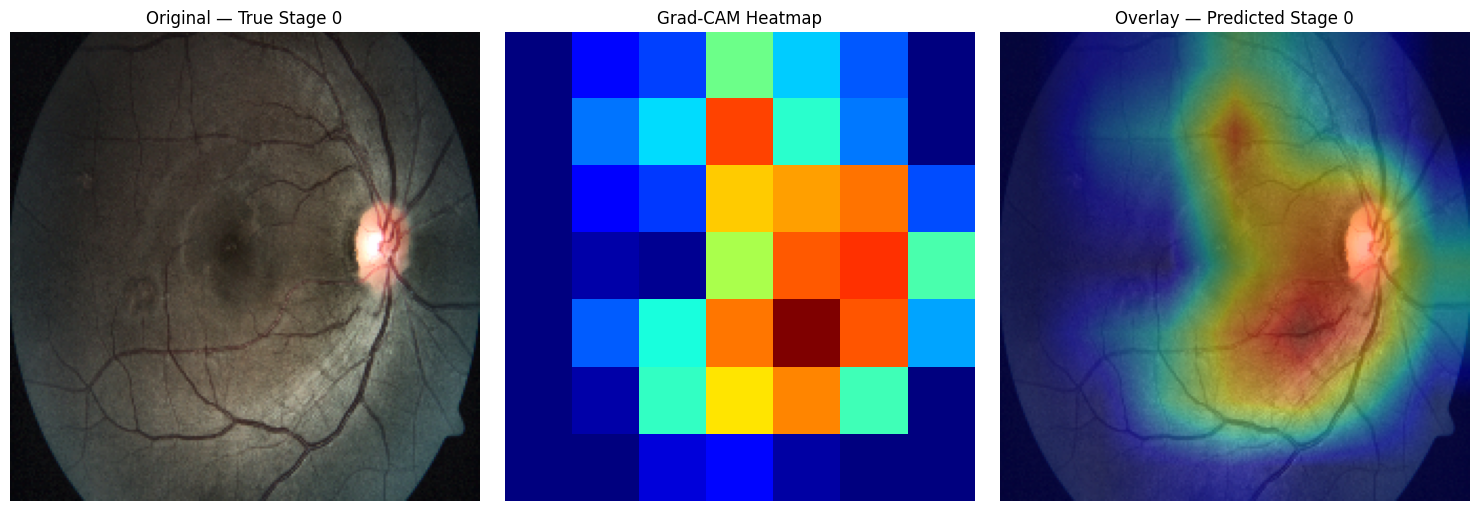

In [11]:
def overlay_gradcam(img_original, heatmap, alpha=0.4):
    # Resize heatmap to match image size
    heatmap_resized = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)

    # Apply colormap (jet — blue=low importance, red=high importance)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]
    jet_heatmap = np.uint8(jet_heatmap * 255)

    # Overlay on original image
    superimposed = jet_heatmap * alpha + img_original * (1 - alpha)
    superimposed = np.uint8(superimposed)
    return superimposed

# Test on one test-set image
test_idx = 5  # pick any index
img_array = np.expand_dims(X_test_img_fixed[test_idx], axis=0)
original_img = np.uint8((X_test_img[test_idx]) * 255)  # original 0-1 scaled image back to 0-255

heatmap, predicted_class = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
overlayed = overlay_gradcam(original_img, heatmap)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_img)
axes[0].set_title(f'Original — True Stage {y_test_img[test_idx]}')
axes[0].axis('off')

axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title('Grad-CAM Heatmap')
axes[1].axis('off')

axes[2].imshow(overlayed)
axes[2].set_title(f'Overlay — Predicted Stage {predicted_class}')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DR_Project/models/gradcam_sample.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import matplotlib

In [13]:
def overlay_gradcam(img_original, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)

    jet = matplotlib.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]
    jet_heatmap = np.uint8(jet_heatmap * 255)

    superimposed = jet_heatmap * alpha + img_original * (1 - alpha)
    superimposed = np.uint8(superimposed)
    return superimposed

Found 73 severe/proliferative test images


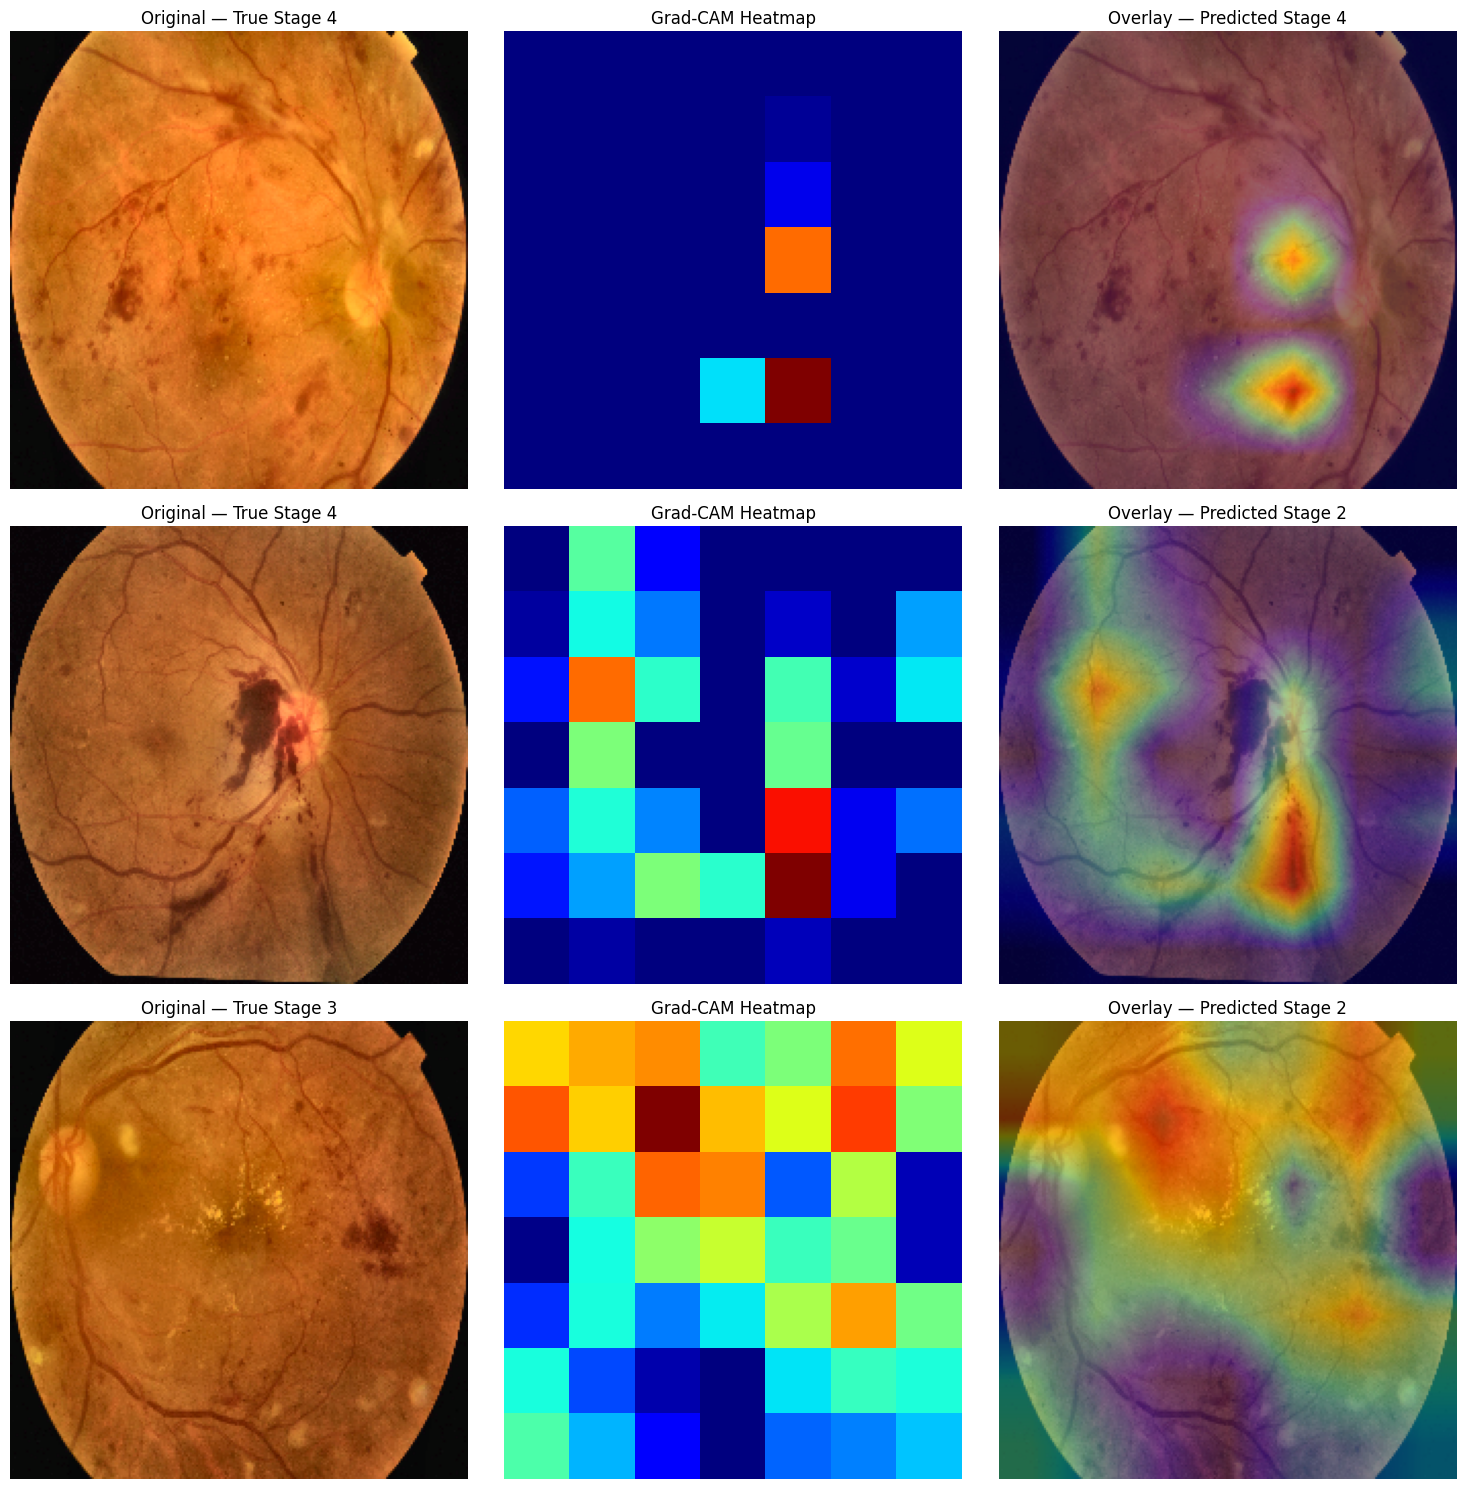

In [14]:
# Find test images that are Stage 3 or 4 (severe/proliferative — visible lesions)
severe_indices = np.where((y_test_img == 3) | (y_test_img == 4))[0]
print(f"Found {len(severe_indices)} severe/proliferative test images")

# Show Grad-CAM for 3 severe examples
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row, idx in enumerate(severe_indices[:3]):
    img_array = np.expand_dims(X_test_img_fixed[idx], axis=0)
    original_img = np.uint8((X_test_img[idx]) * 255)

    heatmap, predicted_class = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    overlayed = overlay_gradcam(original_img, heatmap)

    axes[row, 0].imshow(original_img)
    axes[row, 0].set_title(f'Original — True Stage {y_test_img[idx]}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title('Grad-CAM Heatmap')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlayed)
    axes[row, 2].set_title(f'Overlay — Predicted Stage {predicted_class}')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DR_Project/models/gradcam_severe_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
import shutil
# Already saved via savefig, but let's confirm it's on Drive
import os
print(os.path.exists('/content/drive/MyDrive/DR_Project/models/gradcam_severe_examples.png'))

True


In [16]:
import tensorflow.keras.backend as K

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss

# Recompile the current model with focal loss instead of categorical crossentropy
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

print("Model recompiled with focal loss.")

Model recompiled with focal loss.


In [19]:
callbacks_focal = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint(f'{MODEL_SAVE_PATH}/mobilenetv2_focal_loss.keras',
                     monitor='val_accuracy', save_best_only=True)
]

history_focal = model.fit(
    X_train_img_fixed, y_train_cat,
    validation_data=(X_val_img_fixed, y_val_cat),
    batch_size=32,
    epochs=25,
    callbacks=callbacks_focal,
    verbose=1
)

Epoch 1/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 74s 515ms/step - accuracy: 0.7909 - loss: 0.0660 - val_accuracy: 0.7869 - val_loss: 0.0988
Epoch 2/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7932 - loss: 0.0607 - val_accuracy: 0.7923 - val_loss: 0.0945
Epoch 3/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8119 - loss: 0.0543 - val_accuracy: 0.7887 - val_loss: 0.0967
Epoch 4/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8166 - loss: 0.0538 - val_accuracy: 0.7923 - val_loss: 0.0939
Epoch 5/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8287 - loss: 0.0506 - val_accuracy: 0.7996 - val_loss: 0.0908
Epoch 6/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8307 - loss: 0.0483 - val_accuracy: 0.8015 - val_loss: 0.0878
Epoch 7/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8361 - loss: 0.0456 - val_accuracy: 0.8015 - val_loss: 0.0884
Epoch 8/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8389 - loss: 0.0471 - val_accuracy: 0.8033 -

In [20]:
# Load best weights (restored automatically by EarlyStopping) and evaluate on test set
y_pred_proba_focal = model.predict(X_test_img_fixed)
y_pred_focal = np.argmax(y_pred_proba_focal, axis=1)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, cohen_kappa_score

print("=== Focal Loss Model — Test Set Results ===\n")

test_accuracy_focal = np.mean(y_pred_focal == y_test_img)
print(f"Test Accuracy: {test_accuracy_focal:.4f}")

auc_focal = roc_auc_score(y_test_cat, y_pred_proba_focal, multi_class='ovr')
print(f"AUC-ROC (macro, one-vs-rest): {auc_focal:.4f}")

# Quadratic Weighted Kappa — the standard DR grading metric
qwk = cohen_kappa_score(y_test_img, y_pred_focal, weights='quadratic')
print(f"Quadratic Weighted Kappa: {qwk:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test_img, y_pred_focal, target_names=['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test_img, y_pred_focal))

18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 891ms/step
=== Focal Loss Model — Test Set Results ===

Test Accuracy: 0.7727
AUC-ROC (macro, one-vs-rest): 0.9187
Quadratic Weighted Kappa: 0.8497

=== Classification Report ===
              precision    recall  f1-score   support

     Stage 0       0.96      0.98      0.97       271
     Stage 1       0.48      0.46      0.47        56
     Stage 2       0.68      0.75      0.72       150
     Stage 3       0.32      0.28      0.30        29
     Stage 4       0.45      0.30      0.36        44

    accuracy                           0.77       550
   macro avg       0.58      0.55      0.56       550
weighted avg       0.76      0.77      0.76       550


=== Confusion Matrix ===
[[265   6   0   0   0]
 [  5  26  24   0   1]
 [  4  21 113  10   2]
 [  1   0   7   8  13]
 [  2   1  21   7  13]]


In [21]:
def predict_with_tta(model, images, n_augments=5):
    predictions = []

    # Original prediction
    predictions.append(model.predict(images, verbose=0))

    # Horizontal flip
    flipped = tf.image.flip_left_right(images).numpy()
    predictions.append(model.predict(flipped, verbose=0))

    # Slight rotations
    for angle in [-10, 10]:
        rotated = tf.keras.preprocessing.image.apply_affine_transform
        rotated_batch = np.array([
            tf.keras.preprocessing.image.random_rotation(img, angle, row_axis=0, col_axis=1, channel_axis=2)
            for img in images
        ])
        predictions.append(model.predict(rotated_batch, verbose=0))

    # Brightness variation
    brightened = tf.image.adjust_brightness(images, 0.1).numpy()
    predictions.append(model.predict(brightened, verbose=0))

    # Average all predictions
    avg_pred = np.mean(predictions, axis=0)
    return avg_pred

# Run TTA prediction on test set
y_pred_proba_tta = predict_with_tta(model, X_test_img_fixed)
y_pred_tta = np.argmax(y_pred_proba_tta, axis=1)

test_accuracy_tta = np.mean(y_pred_tta == y_test_img)
auc_tta = roc_auc_score(y_test_cat, y_pred_proba_tta, multi_class='ovr')
qwk_tta = cohen_kappa_score(y_test_img, y_pred_tta, weights='quadratic')

print("=== TTA Results ===")
print(f"Test Accuracy: {test_accuracy_tta:.4f}")
print(f"AUC-ROC: {auc_tta:.4f}")
print(f"QWK: {qwk_tta:.4f}")
print("\n", classification_report(y_test_img, y_pred_tta, target_names=['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']))

=== TTA Results ===
Test Accuracy: 0.7800
AUC-ROC: 0.9204
QWK: 0.8625

               precision    recall  f1-score   support

     Stage 0       0.96      0.97      0.97       271
     Stage 1       0.57      0.41      0.48        56
     Stage 2       0.68      0.79      0.73       150
     Stage 3       0.26      0.24      0.25        29
     Stage 4       0.48      0.36      0.42        44

    accuracy                           0.78       550
   macro avg       0.59      0.56      0.57       550
weighted avg       0.77      0.78      0.77       550



In [22]:
model.save(f'{MODEL_SAVE_PATH}/mobilenetv2_final_v4_tta.keras')

final_results_v4 = {
    'test_accuracy': float(test_accuracy_tta),
    'auc_roc_macro': float(auc_tta),
    'quadratic_weighted_kappa': float(qwk_tta),
    'technique': 'MobileNetV2 + focal loss + two-phase fine-tuning + test-time augmentation',
    'iteration_history': {
        'v1_baseline': {'accuracy': 0.764, 'auc_roc': 0.901},
        'v2_class_weighted': {'accuracy': 0.760, 'auc_roc': 0.911},
        'v3_focal_loss': {'accuracy': 0.773, 'auc_roc': 0.919, 'qwk': 0.850},
        'v4_focal_loss_tta': {'accuracy': 0.780, 'auc_roc': 0.920, 'qwk': 0.863}
    }
}

import json
with open(f'{MODEL_SAVE_PATH}/model2_final_results.json', 'w') as f:
    json.dump(final_results_v4, f, indent=2)

print("Final Model 2 locked in and saved.")

Final Model 2 locked in and saved.
